In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s5e11')

print("Path to competition files:", path)

d:\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to competition files: C:\Users\赵一儒\.cache\kagglehub\competitions\playground-series-s5e11


In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix, 
                             accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.sans-serif']=['SimHei']

rand_seed = 6767

In [3]:
df = pd.read_csv("C:\\Users\\赵一儒\\.cache\\kagglehub\\competitions\\playground-series-s5e11\\train.csv")
df.drop(columns='id',inplace=True)
print(f"数据集形状：{df.shape}")
print(f"目标变量分布：\n{df['loan_paid_back'].value_counts()}")
display(df.head())

数据集形状：(593994, 12)
目标变量分布：
loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64


,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [4]:
# 特征工程，新增三个特征
# 贷款金额与年收入的比值
df['loan_to_income'] = df['loan_amount'] / df['annual_income']
# 债务收入比与贷款金额的乘积，代表绝对的债务压力情况
df['debt_to_loan_interact'] = df['debt_to_income_ratio']
# 每单位信用分的收入情况
df['income_per_credit'] = df['annual_income'] / df['credit_score']

In [5]:
# 数据处理
X = df.drop(columns='loan_paid_back')
y = df['loan_paid_back']

cat_f = X.select_dtypes(include=['object']).columns.tolist()
num_f = X.select_dtypes(include=['int64','float64']).columns.tolist()
print('分类型特征',cat_f)
print('数值型特征',num_f)

encoder = OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)
X_cat_encoded = encoder.fit_transform(X[cat_f])
X_cat_encoded = pd.DataFrame(X_cat_encoded,columns=cat_f)

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X[num_f])
X_num_scaled = pd.DataFrame(X_num_scaled, columns=num_f)

X_final = pd.concat([X_num_scaled,X_cat_encoded], axis=1)
f_name = num_f + cat_f
print(X_final.shape)
print(f"最终特征数：{len(f_name)}")

分类型特征 ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
数值型特征 ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_to_income', 'debt_to_loan_interact', 'income_per_credit']
(593994, 14)
最终特征数：14


In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_final, y, test_size=0.2, random_state=rand_seed, stratify=y 
)
print(f"训练集：{X_train.shape}，验证集：{X_val.shape}")

训练集：(475195, 14)，验证集：(118799, 14)


In [22]:
lgb_model = lgb.LGBMClassifier(
    # class_weight='balanced',
    objective='binary',
    boosting_type='gbdt',
    n_estimators=1500,
    learning_rate=0.05,
    num_leaves=34,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=rand_seed,
    n_jobs=-1,
    verbose=1
)

eval_set = [(X_train,y_train),(X_val,y_val)]
lgb_model.fit(
    X_train,y_train,
    eval_set=eval_set,
    eval_metric='logloss',
    callbacks=[lgb.early_stopping(stopping_rounds=100,verbose = 1)]
)
print(lgb_model)

[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004096 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2094
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798819 -> initscore=1.378932
[LightGBM] [Info] Start training from score 1.378932
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1186]	training's binary_logloss: 0.223805	valid_1's binary_logloss: 0.246301
LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, min_child_samples=40,
               n_estimators=1500, n_jobs=-1, num_leaves=34, objective='binary',
               random_state=6767, reg_alpha=0.1, reg_lambda=0.1, subsample=0.8,
               verbose=1)



lightGBM 验证集准确率：0.9053
分类报告：
               precision    recall  f1-score   support

         未还清       0.88      0.61      0.72     23900
         已还清       0.91      0.98      0.94     94899

    accuracy                           0.91    118799
   macro avg       0.90      0.80      0.83    118799
weighted avg       0.90      0.91      0.90    118799

混淆矩阵：
 [[14598  9302]
 [ 1952 92947]]


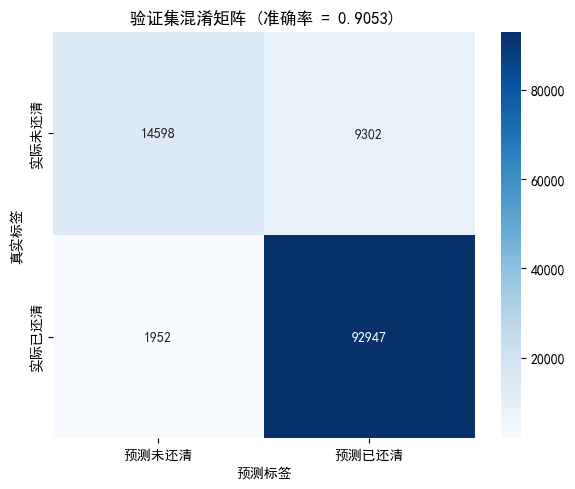

In [23]:
y_pred = lgb_model.predict(X_val)
acc = accuracy_score(y_val, y_pred)
cm = confusion_matrix(y_val, y_pred)
print(f"\nlightGBM 验证集准确率：{acc:.4f}")
print("分类报告：\n",classification_report(y_val,y_pred,target_names=['未还清','已还清']))
print('混淆矩阵：\n',cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['预测未还清', '预测已还清'],
            yticklabels=['实际未还清', '实际已还清'])
plt.title(f'验证集混淆矩阵 (准确率 = {acc:.4f})')
plt.ylabel('真实标签')
plt.xlabel('预测标签')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

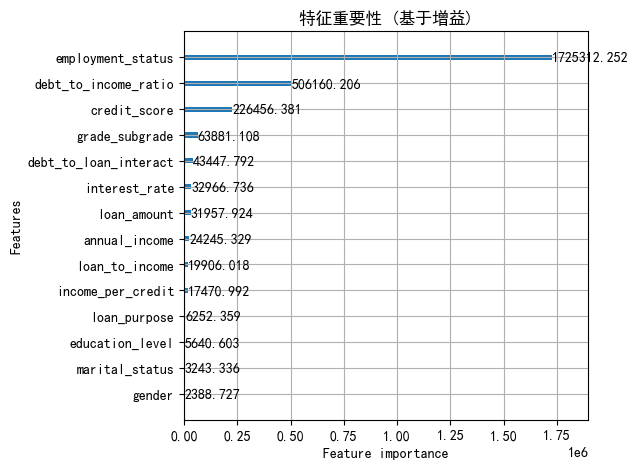

In [25]:
# 绘制特征重要性图
plt.figure(figsize=(10,6))
lgb.plot_importance(lgb_model, importance_type='gain')
plt.title('特征重要性 (基于增益)')
plt.tight_layout()
plt.show()